In [1]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2
# imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from neural_net import NeuralNet
import mushrooms as shroom
import graphics
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

In [2]:
mnist = fetch_openml('mnist_784', as_frame=False)
X, y = mnist.data, mnist.target
X = np.array(X)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, stratify=y, random_state=42)

In [4]:
y = np.astype(y, int)
y_processed = np.zeros((len(y), 10))
for i, y_p in enumerate(y_processed):
    y_p[y[i]] =1

y = y_processed 
X = X/255
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [ ]:
neural_net = NeuralNet((28**2, 256, 10), learning_rate=0.001, random_state=42)
neural_net.layers[0].activation_method="ReLu"
neural_net.layers[0].weights = neural_net.layers[0].initialize("He")
neural_net.layers[-1].activation_method="softmax"
epochs = 10
losses, y_pred = neural_net.train(X_train,
                                  y_train,
                                  epochs,
                                  batch_size = 32,
                                  validate=(X_test, y_test),
                                  categorical=True,
                                  lr_scheduling=True,
                                  dropout=True,
                                  noise_normalization=True)


EPOCH: 1    LOSS: 0.0448289    LOSS CHANGE: 0    TEST ACCURACY: 0.9499    TEST ACCURACY CHANGE 0.9499
EPOCH: 2    LOSS: 0.0211094    LOSS CHANGE: -0.02372    TEST ACCURACY: 0.9666    TEST ACCURACY CHANGE 0.01671
EPOCH: 3    LOSS: 0.015504    LOSS CHANGE: -0.005605    TEST ACCURACY: 0.9732    TEST ACCURACY CHANGE 0.006571
EPOCH: 4    LOSS: 0.0122453    LOSS CHANGE: -0.003259    TEST ACCURACY: 0.9752    TEST ACCURACY CHANGE 0.002
EPOCH: 5    LOSS: 0.0103764    LOSS CHANGE: -0.001869    TEST ACCURACY: 0.9769    TEST ACCURACY CHANGE 0.001714
EPOCH: 6    LOSS: 0.00916016    LOSS CHANGE: -0.001216    TEST ACCURACY: 0.9766    TEST ACCURACY CHANGE -0.0002857
EPOCH: 7    LOSS: 0.00781935    LOSS CHANGE: -0.001341    TEST ACCURACY: 0.9779    TEST ACCURACY CHANGE 0.001286
EPOCH: 8    LOSS: 0.007242    LOSS CHANGE: -0.0005773    TEST ACCURACY: 0.9778    TEST ACCURACY CHANGE -0.0001429
EPOCH: 9    LOSS: 0.00684134    LOSS CHANGE: -0.0004007    TEST ACCURACY: 0.9791    TEST ACCURACY CHANGE 0.001286


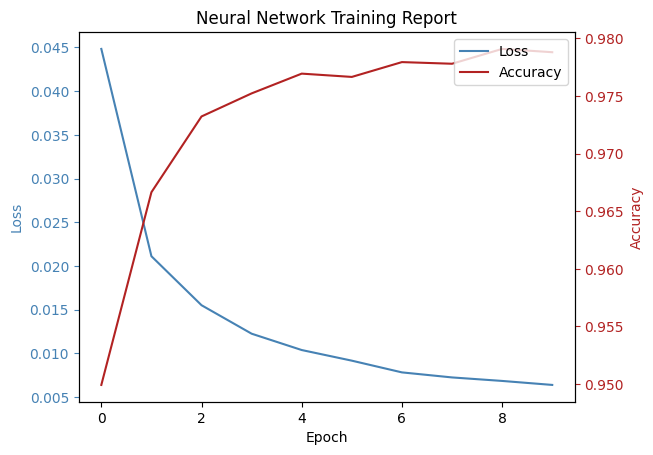

In [255]:
graphics.plot_report(neural_net)

In [256]:
neural_net.export("models/MNIST_net.h5")

Neural Network exported to models/MNIST_net.h5


In [257]:
from sklearn.metrics import accuracy_score

y_pred = neural_net.predict(X_test)
y_pred_accuracy = np.where(y_pred > 0.5, 1, 0)

Accuracy: 0.9787857142857143


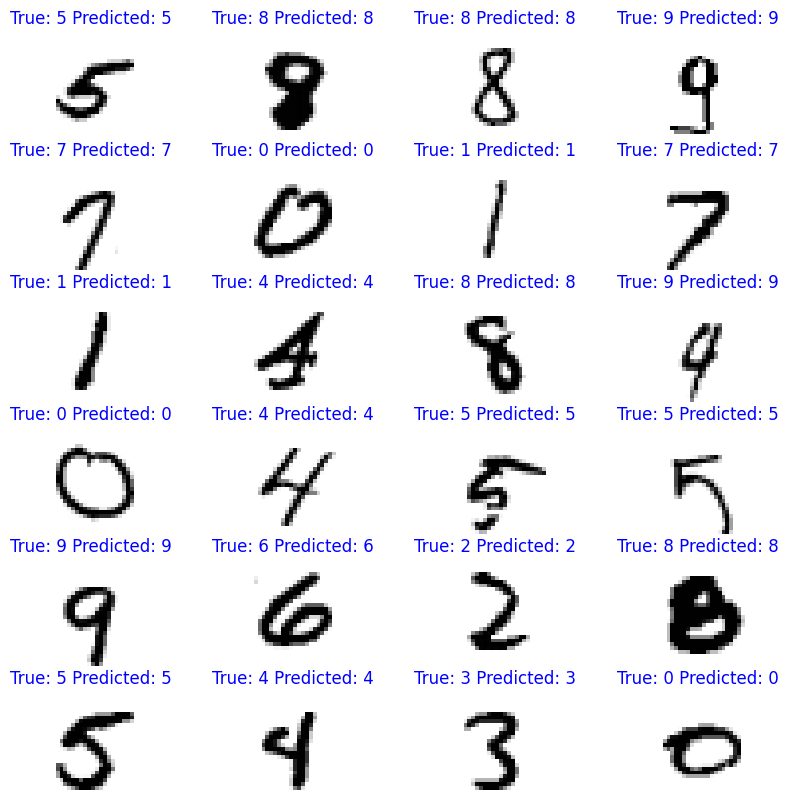

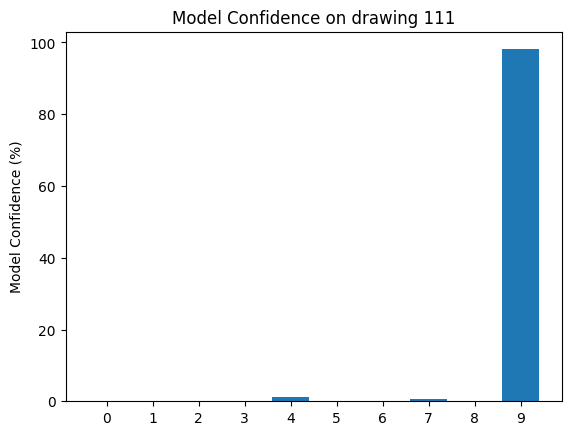

Prediction: [2.71706852e-08 9.57765718e-05 1.60569624e-09 6.45458509e-08
 1.19125488e-02 2.04616177e-07 4.80908192e-11 6.93123133e-03
 2.53637654e-11 9.81060145e-01]


In [258]:
print(f"Accuracy: {accuracy_score(y_pred_accuracy, y_test)}")

def display_num(ax, X, i, true, pred):
    X_image = np.swapaxes(np.array(np.split(X, 28, axis=1)), 1, 0)
    ax.imshow(X_image[i], cmap="gray_r")
    ax.set_title(f'True: {true} Predicted: {pred}', c="blue" if true == pred else "red")
    ax.axis('off') # Hide axis ticks

rows = 6
cols = 4

fig, axs = plt.subplots(rows, cols, figsize=(10, 10))

for i in range(24):
    current_row = i // cols
    current_col = i % cols
    
    # Select the correct subplot axis
    ax = axs[current_row, current_col]
    display_num(ax, X_test, i+100, y_test.argmax(axis=1)[i+100], y_pred.argmax(axis=1)[i+100])
plt.show()
plt.title(f"Model Confidence on drawing {11+100}")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred[11+100].flatten())
plt.xticks(np.arange(10))
plt.show()
print(f"Prediction: {y_pred[11+100]}")

Pred: [[1.97506152e-09 1.69396478e-21 2.55446921e-01 7.36131517e-01
  3.64436410e-30 3.28841604e-04 8.09271774e-03 1.05014484e-17
  1.22266499e-09 1.93742713e-23]]


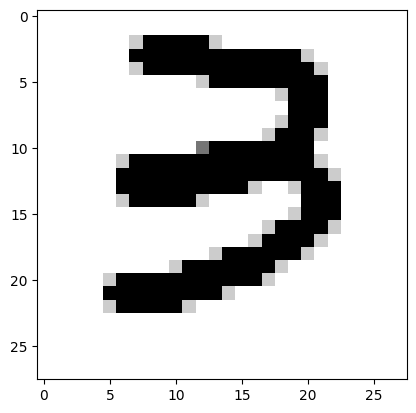

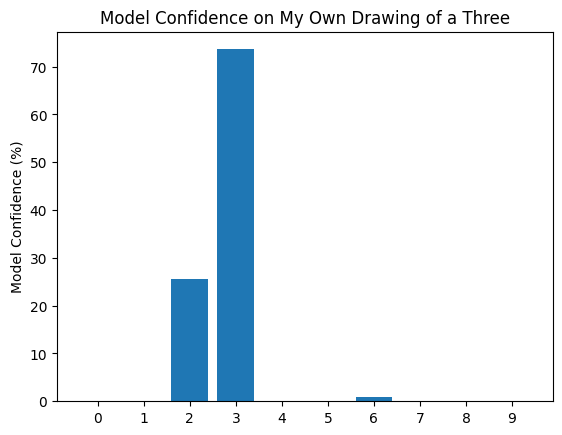

In [259]:
# can it predict my own writing?

my_three = plt.imread('three.png')[:, :28, 0]
X_my = np.array([(1 - my_three).flatten()])
y_pred_my = neural_net.predict(X_my)
print(f"Pred: {y_pred_my}")
plt.imshow(my_three, cmap="gray")
plt.show()
plt.title("Model Confidence on My Own Drawing of a Three")
plt.ylabel("Model Confidence (%)")
plt.bar(np.arange(10), 100*y_pred_my.flatten())
plt.xticks(np.arange(10))
plt.show()